# 02. Experimental Testing & Evaluation

**Goal:**  
Evaluate the Bigram + Hard IDF experimental model on unseen validation data and compare performance against the baseline.

**Pipeline Overview:**
1. **Data Ingestion:** Load preprocessed validation data (`val_cleaned.csv`).
2. **Experimental Artifact Loading:** Ingest `exp_vectorizer.pkl` and `exp_naive_bayes_model.pkl`.
3. **Strict Transformation:** Transform text features into bigram space using `.transform()`.
4. **Evaluation:** Calculate Macro-F1, per-class metrics, and visualize the updated confusion matrix.

In [23]:
import sys
import os
import pickle
import pandas as pd
import numpy as np

# Ensure Python can locate custom modules inside src/
sys.path.append(os.path.abspath("../src"))

from preprocessing import transform_new_data
from naive_bayes import MultinomialNaiveBayes
from metrics import compute_classification_metrics, plot_confusion_matrix

# Load preprocessed validation set
val_data_path = "../data/processed/validation_cleaned.csv"
df_val = pd.read_csv(val_data_path).dropna(subset=['tweet_content'])

print(f"Loaded validation samples: {len(df_val)}")

Loaded validation samples: 827


## 2. Load Experimental Binaries

We load the bigram vectorizer and experimental Naive Bayes model preserved during the experimental training run.

In [24]:
models_dir = "../models"

# Load experimental vectorizer
vectorizer_path = os.path.join(models_dir, "exp_vectorizer.pkl")
with open(vectorizer_path, "rb") as f:
    exp_vectorizer = pickle.load(f)

# Load experimental model
model_path = os.path.join(models_dir, "exp_naive_bayes_model.pkl")
exp_model = MultinomialNaiveBayes.load_model(model_path)

print(f"Loaded Experimental Vectorizer (Vocabulary Size: {len(exp_vectorizer.vocabulary_)})")
print(f"Loaded Experimental Model Classes: {exp_model.classes_}")

Loaded Experimental Vectorizer (Vocabulary Size: 20068)
Loaded Experimental Model Classes: ['Negative' 'Neutral' 'Positive']


## 3. Strict Feature Transformation

We pass validation text into `transform_new_data` using the experimental vectorizer. This generates the matching feature columns, incorporating bigram features extracted during training.

In [25]:
X_val_text = df_val['tweet_content']
y_true = df_val['sentiment'].values

# Transform validation text strictly (no fitting)
X_val_sparse = transform_new_data(exp_vectorizer, X_val_text)

print(f"Experimental Validation Matrix Shape: {X_val_sparse.shape}")

Experimental Validation Matrix Shape: (827, 20068)


## 4. Experimental Inference

We run inference across the experimental validation matrix to generate predicted sentiment labels.

In [26]:
# Generate predictions
y_pred_exp = exp_model.predict(X_val_sparse)

# Sanity check
print("First 10 Experimental Predictions vs Actuals:")
for i in range(10):
    print(f"Predicted: {y_pred_exp[i]:<10} | Actual: {y_true[i]}")

First 10 Experimental Predictions vs Actuals:
Predicted: Neutral    | Actual: Neutral
Predicted: Negative   | Actual: Negative
Predicted: Negative   | Actual: Negative
Predicted: Neutral    | Actual: Neutral
Predicted: Negative   | Actual: Negative
Predicted: Positive   | Actual: Positive
Predicted: Positive   | Actual: Positive
Predicted: Positive   | Actual: Positive
Predicted: Negative   | Actual: Negative
Predicted: Negative   | Actual: Positive


## 5. Metrics & Heatmap Visualization

We compute metrics using `src/metrics.py` and plot the confusion matrix heatmap to evaluate changes in Neutral class recall and overall Macro-F1 performance.

EXPERIMENTAL ACCURACY:  0.8404
EXPERIMENTAL MACRO F1:  0.8401

--- PER-CLASS METRICS ---
Class: Negative
  Precision: 0.8278
  Recall:    0.8496
  F1-Score:  0.8386
  Support:   266
-------------------------
Class: Neutral
  Precision: 0.8750
  Recall:    0.7860
  F1-Score:  0.8281
  Support:   285
-------------------------
Class: Positive
  Precision: 0.8221
  Recall:    0.8877
  F1-Score:  0.8537
  Support:   276
-------------------------
Visualized confusion matrix saved to ../models/exp_confusion_matrix.png


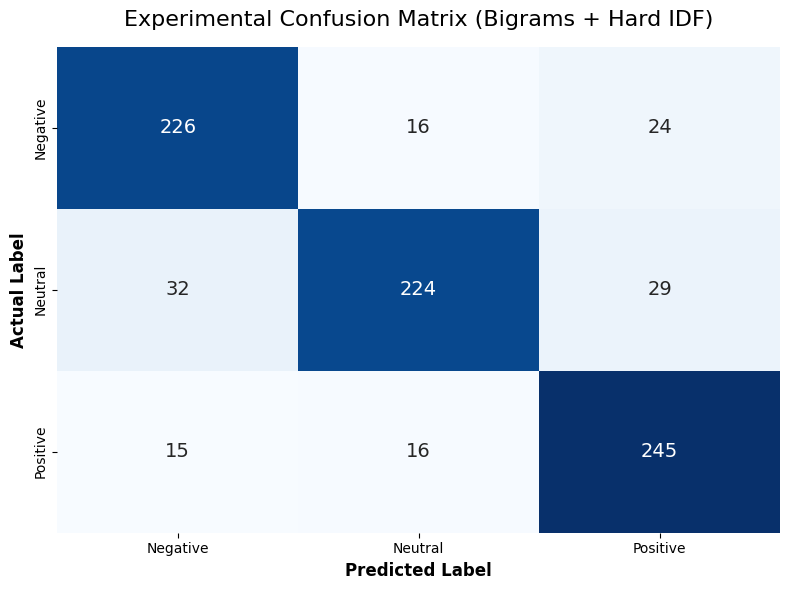

In [27]:
# Calculate classification metrics
exp_results = compute_classification_metrics(y_true, y_pred_exp, classes=exp_model.classes_)

# Print summary
print("="*40)
print(f"EXPERIMENTAL ACCURACY:  {exp_results['accuracy']:.4f}")
print(f"EXPERIMENTAL MACRO F1:  {exp_results['macro']['macro_f1']:.4f}")
print("="*40)

# Per-Class breakdown
print("\n--- PER-CLASS METRICS ---")
for c in exp_results['classes']:
    metrics = exp_results['per_class'][c]
    print(f"Class: {c}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1-Score:  {metrics['f1_score']:.4f}")
    print(f"  Support:   {metrics['support']}")
    print("-" * 25)

# Render Confusion Matrix Heatmap
plot_confusion_matrix(
    cm=exp_results['confusion_matrix'], 
    classes=exp_results['classes'], 
    title="Experimental Confusion Matrix (Bigrams + Hard IDF)",
    save_path="../models/exp_confusion_matrix.png"
)

## Final Observations & Matrix Analysis

### Baseline Configuration
This notebook establishes **`max_df = 0.10` with bigrams (`ngram_range=(1, 2)`)** as the primary experimental baseline. This setup yields an **84.04% Accuracy** and **84.01% Macro-F1**, outperforming the initial unigram baseline across all key metrics.

---

### Core Performance Wins
* **Neutral Bleed Reduction:** Neutral class misclassifications dropped by **29%** (from 86 down to 61 errors). Neutral Recall increased from **69.82% to 78.60%**.
* **Contextual Bigrams:** Including word pairs enabled the model to capture negation and sentiment phrases (e.g., *"not good"*), preventing neutral sentences with mild positive/negative terms from being pulled into wrong classes.
* **Balanced Class Performance:** Improvements were universal across classes, elevating Positive F1 to **85.37%** and Negative F1 to **83.86%**.

---

### Hyperparameter Sensitivity (`max_df` Sweep)

Testing varying thresholds for `max_df` demonstrated clear diminishing returns, pointing to a distinct sweet spot between removing corpus-wide noise and retaining sentiment context:

* **`max_df = 0.40` (Accuracy: 83.31% | Macro-F1: 83.30%):** Outperformed the baseline unigram model, but still retained high-frequency entity noise (game names, platform handles) that biased class priors.
* **`max_df = 0.10` (Accuracy: 84.04% | Macro-F1: 84.01%):** Optimal performance threshold. Effectively stripped domain-specific entity noise without removing sentiment-bearing tokens.
* **`max_df = 0.07` (Accuracy: 84.28% | Macro-F1: 84.25%):** Showed marginal gains (~0.24% F1 lift) as it reached the narrow 7%–10% document frequency band.
* **`max_df = 0.05` (Accuracy: ~84.20% | Plateau):** Performance stabilized completely. Lowering the threshold further risks stripping key sentiment indicators that occur naturally at moderate frequencies.

---

### Vocabulary & Sparse Matrix Mechanics

* **Feature Count Stability (`n_features`):** Dropping `max_df` from `0.50` all the way down to `0.05` pruned only **38 unique features** out of 20,086 (a negligible **0.19% reduction** in vocabulary width). 
* **Active Entry Eradication (`nnz`):** Despite removing only 38 features, total non-zero elements dropped by **271,333 active instances** (a **20.5% reduction** in total matrix data).